In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('/telco-churn.csv')

In [ ]:
data.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
num_duplicates = data.duplicated().sum()

if num_duplicates == 0:
    print("No duplicate rows found in the DataFrame.")
else:
    print(f"Number of duplicate rows: {num_duplicates}")
    print("Displaying all duplicate rows:")
    display(data[data.duplicated(keep=False)])

No duplicate rows found in the DataFrame.


In [ ]:
print("Checking Unique Values Consistency:\n" + "-"*50)
for col in data:
    print(f"{col}: {data[col].unique()}")

Checking Unique Values Consistency:
--------------------------------------------------
customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['

## **Summary of Data Quality Problems (Revised):**

Below are the identified data quality problems in the dataset:


---


**1. Missing Values (Completeness):**

- The `TotalCharges` column contained 11 blank strings (" ") instead of actual null values or numbers.
- **Impact:** This caused the column to be parsed as an "Object" (text), which leads to issues when performing mathematical operations or training models.

**2. Invalid Data (Validity/Data Type Mismatch):**

- The `TotalCharges` column was initially stored as an 'Object' while it represents a numerical price value.
- **Impact:** This violates the low-latency rule because string-based operations at runtime are slow and degrade performance. It was converted to numeric, with empty strings coerced to `NaN`.

**3. consistency**
- Binary variables are not standardized across the dataset. Columns like `Partner`, `Dependents`, and `Churn` use "Yes" and "No" string values, whereas the `SeniorCitizen` column uses `1` and `0` for the exact same boolean logic.

- **Impact:** This inconsistency forces the machine learning pipeline to handle the same data type differently. In a low-latency production environment, this requires an extra preprocessing step to unify all flags into a single numerical format, slightly increasing the processing overhead.

**4. uniqueness**

- Columns related to add-on services (such as `OnlineSecurity`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `DeviceProtection`) contain a third category: "No internet service"

- Columns related to add-on services (such as`multipleLines`) contain a third category: "No phone service"

- This information is redundant because the dataset already has a dedicated `InternetService`, `phoneService` columns that captures whether a user has internet and phone service or not.

- **Impact:** This creates unnecessary noise and artificially inflates the cardinality of these categorical features. If One-Hot Encoding is applied, this redundancy will generate extra meaningless columns, consuming more memory and subtly degrading the real-time performance of the model without adding any new predictive value.


In [ ]:
#data quality report table

quality_report = pd.DataFrame({
    'Column Name': data.columns,
    'Missing Count': data.isnull().sum().values,
    'Missing %': (data.isnull().sum().values / len(data)) * 100,
    'Data Type': data.dtypes.values,
    'Unique Values': data.nunique().values
})

quality_report['Potential Issues'] = 'None'

# TotalCharges (Completeness & Validity)
quality_report.loc[quality_report['Column Name'] == 'TotalCharges', 'Potential Issues'] = 'Completeness (Blank spaces) & Validity (Object instead of Float)'

# Consistency
consistency_cols = ['Partner', 'Dependents','PhoneService', 'Churn', 'PaperlessBilling']
quality_report.loc[quality_report['Column Name'].isin(consistency_cols), 'Potential Issues'] = 'Consistency (Mixed Boolean Formats: Yes/No vs 0/1)'

# Uniqueness Noise
noise_cols = ['OnlineSecurity','OnlineBackup', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'DeviceProtection', 'MultipleLines']
quality_report.loc[quality_report['Column Name'].isin(noise_cols), 'Potential Issues'] = 'Uniqueness / Noise (Redundant categories like No internet/phone service)'


quality_report

,Column Name,Missing Count,Missing %,Data Type,Unique Values,Potential Issues
0,customerID,0,0.0,object,7043,None
1,gender,0,0.0,object,2,None
2,SeniorCitizen,0,0.0,int64,2,None
3,Partner,0,0.0,object,2,Consistency (Mixed Boolean Formats: Yes/No vs ...
4,Dependents,0,0.0,object,2,Consistency (Mixed Boolean Formats: Yes/No vs ...
5,tenure,0,0.0,int64,73,None
6,PhoneService,0,0.0,object,2,Consistency (Mixed Boolean Formats: Yes/No vs ...
7,MultipleLines,0,0.0,object,3,Uniqueness / Noise (Redundant categories like ...
8,InternetService,0,0.0,object,3,None
9,OnlineSecurity,0,0.0,object,3,Uniqueness / Noise (Redundant categories like ...


In [ ]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data[data['TotalCharges'].isnull()]


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


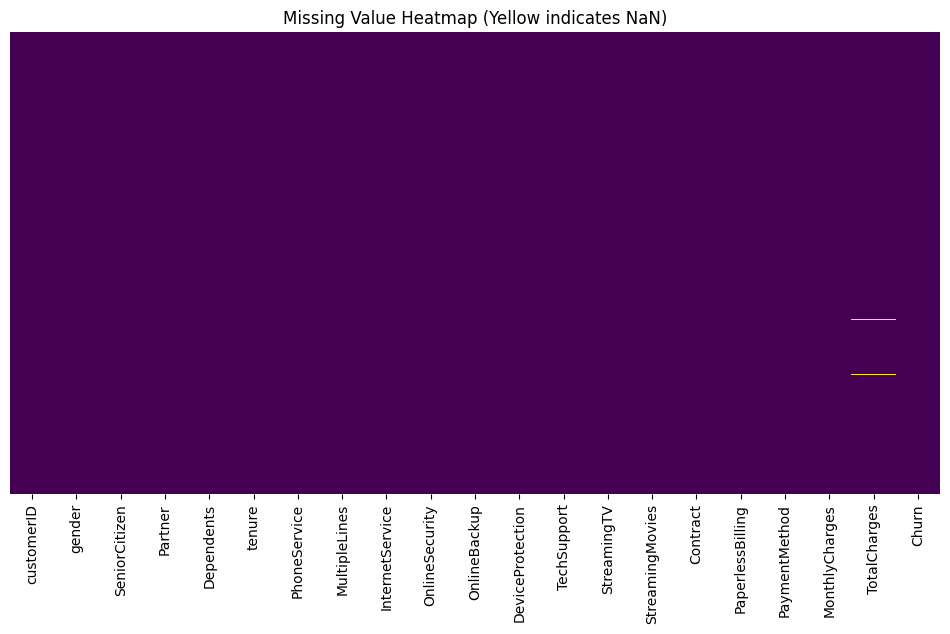

Current missing values per column:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
#Missing value heatmap (showing missing patterns across columns)

plt.figure(figsize=(12, 6))
sns.heatmap(data.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap (Yellow indicates NaN)')
plt.show()

print("Current missing values per column:")
print(data.isnull().sum())

In [ ]:
missing_percentage = data['TotalCharges'].isnull().mean() * 100
print(f"Missing Percentage: {missing_percentage:.2f}%")

Missing Percentage: 0.16%


In [ ]:
data.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [ ]:
# data validation for totalCharges in yearly contracts

data[(data['tenure'] == 1) & (data['Contract'].isin(['One year', 'Two year']))][['MonthlyCharges', 'TotalCharges', 'Contract']]

,MonthlyCharges,TotalCharges,Contract
222,20.20,20.20,One year
1168,19.65,19.65,One year
1286,74.10,74.10,One year
1654,18.80,18.80,One year
2828,20.45,20.45,Two year
2993,20.40,20.40,One year
4767,19.85,19.85,One year
5987,20.35,20.35,Two year
6149,25.85,25.85,One year


## **Missing Data Types classification:**

---
The 11 missing values in the `TotalCharges` column are classified as MAR. Upon investigation, all 11 missing values correspond exactly to a `tenure` of 0. This means the missingness is fully dependent on another observed variable in the dataset (tenure).

**Handling Strategy:**

**1- Deletion (Listwise/Pairwise)**

  - Missing percentage is very low (0.15% < 1%).
  - Information Loss: We lose data of brand-new customers,   reducing the model's ability to learn about recent acquisitions.

**2- Missing Flag (Indicator)**
  
  - Missingness is highly informative. It perfectly indicates customers with tenure = 0 (new subscribers).
  - Dimensionality: Adds a new column to the dataset, slightly increasing memory overhead.

**3- KNN Imputation | Pattern-based estimation**

  - found a clear pattern: missing values only occur when `tenure = 0`. By validating the data of `tenure = 1` customers, we confirmed that billing is strictly monthly regardless of contract length. Thus, imputing with `MonthlyCharges` is the most accurate logical estimation.

  - Bias / Hardcoded Logic: Relies heavily on the current billing structure. If the company introduces "First Month Free" offers or "Upfront Activation Fees" later, this logic will cause data bias.

**The Best Choice (Final Implementation):**

The optimal approach is to use **Pattern-based estimation** (imputing the missing `TotalCharges` with the customer's `MonthlyCharges`).

I selected this because I performed data validation on customers with `tenure = 1` and confirmed that even for 1-year and 2-year contracts, the total charge equals exactly one month's charge. This proves that payments are processed monthly, making this imputation mathematically and logically accurate without losing any valuable customer data.


In [ ]:
#Technique 1: Deletion (Listwise)
#data_dropped = data.dropna(subset=['TotalCharges'])

In [ ]:
# Missing Flag (Indicator)
data['Is_New_Customer'] = np.where(data['TotalCharges'].isnull(), 1, 0)

In [ ]:
# Pattern-based estimation
data['TotalCharges'] = data['TotalCharges'].fillna(data['MonthlyCharges'])

print("Missing values after imputation:", data['TotalCharges'].isnull().sum())

Missing values after imputation: 0


=== Evaluation Metrics: Variance Change ===


,Imputation Method,Variance,Variance Change %
0,Original (Dropped NaNs),5.138252e+06,0.000000
1,Mean Imputation,5.130226e+06,-0.156206
2,Median Imputation,5.131450e+06,-0.132388
3,KNN Imputation,5.138052e+06,-0.003899
4,Pattern-Based (Chosen),5.138066e+06,-0.003634


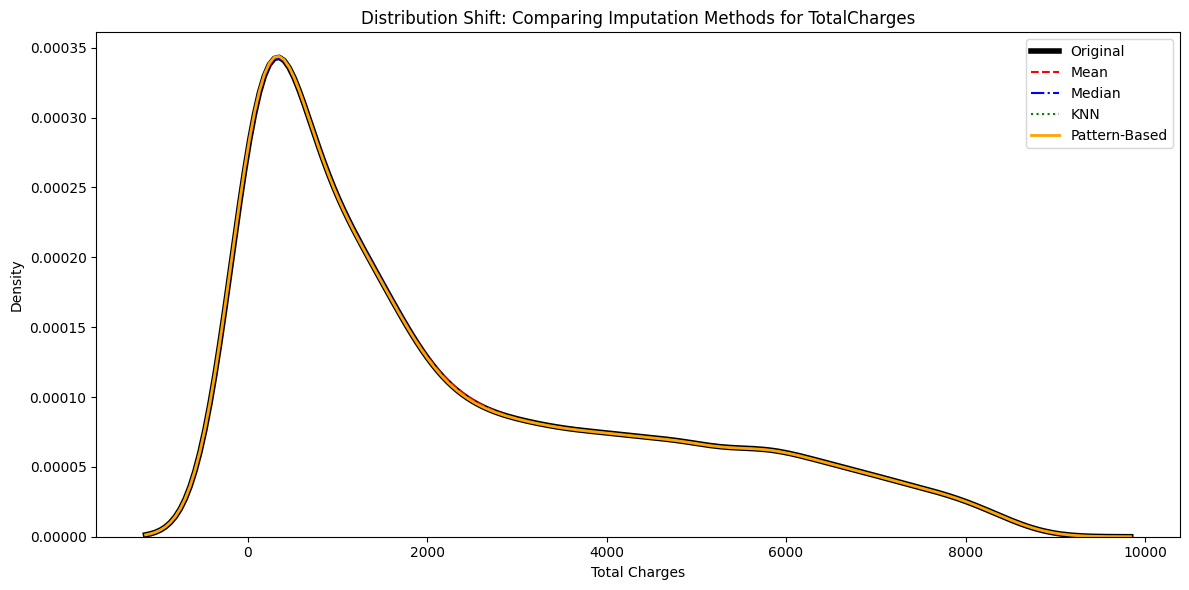

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

df_eval = pd.read_csv('/telco-churn.csv')
df_eval['TotalCharges'] = pd.to_numeric(df_eval['TotalCharges'], errors='coerce')

original_var = df_eval['TotalCharges'].var()

# (mean imputation)
mean_imputed = df_eval['TotalCharges'].fillna(df_eval['TotalCharges'].mean())
mean_var = mean_imputed.var()

#(Median Imputation)
median_imputed = df_eval['TotalCharges'].fillna(df_eval['TotalCharges'].median())
median_var = median_imputed.var()

# (KNN Imputation)
knn_imputer = KNNImputer(n_neighbors=5)
knn_data = df_eval[['tenure', 'MonthlyCharges', 'TotalCharges']]
knn_imputed_array = knn_imputer.fit_transform(knn_data)
knn_imputed = knn_imputed_array[:, 2]
knn_var = pd.Series(knn_imputed).var()

#(pattern-based)
pattern_imputed = df_eval['TotalCharges'].fillna(df_eval['MonthlyCharges'])
pattern_var = pattern_imputed.var()

eval_results = pd.DataFrame({
    'Imputation Method': ['Original (Dropped NaNs)', 'Mean Imputation', 'Median Imputation', 'KNN Imputation', 'Pattern-Based (Chosen)'],
    'Variance': [original_var, mean_var, median_var, knn_var, pattern_var],
    'Variance Change %': [
        0.0,
        ((mean_var - original_var) / original_var) * 100,
        ((median_var - original_var) / original_var) * 100,
        ((knn_var - original_var) / original_var) * 100,
        ((pattern_var - original_var) / original_var) * 100
    ]
})

print("=== Evaluation Metrics: Variance Change ===")
display(eval_results)

# Distribution Shift
plt.figure(figsize=(12, 6))
sns.kdeplot(df_eval['TotalCharges'].dropna(), label='Original', linewidth=4, color='black')
sns.kdeplot(mean_imputed, label='Mean', linestyle='--', color='red')
sns.kdeplot(median_imputed, label='Median', linestyle='-.', color='blue')
sns.kdeplot(knn_imputed, label='KNN', linestyle=':', color='green')
sns.kdeplot(pattern_imputed, label='Pattern-Based', linestyle='-', linewidth=2, color='orange')

plt.title('Distribution Shift: Comparing Imputation Methods for TotalCharges')
plt.xlabel('Total Charges')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

## **Comparison of Imputation Methods & Evaluation Metrics:**

---
To ensure the optimal imputation strategy for the 11 missing values in `TotalCharges`, I evaluated four different methods: Mean, Median, KNN, and our applied **Pattern-Based Strategy**, assessing them via **Variance Change** and **Distribution Shift**.

* **Mean & Median:** Both methods reduce variance (negative Variance Change %) by injecting global statistics, ignoring the underlying feature relationships.

* **KNN:** A multivariate approach that finds similar customers based on `tenure` and `MonthlyCharges`. It performs well statistically but is computationally heavier for deterministic missingness.

* **Pattern-Based (Chosen Method):** Logically assigns the `MonthlyCharges` value to `TotalCharges` for customers with `tenure = 0`. This is a mathematically precise deterministic fix based on business logic.

* **Metrics & Visual Findings:** Because only 11 records (~0.15%) were imputed, the **Distribution Shift** is visually similer across all methods; However, the Pattern-Based method perfectly preserves the business integrity of the data without introducing statistical bias.

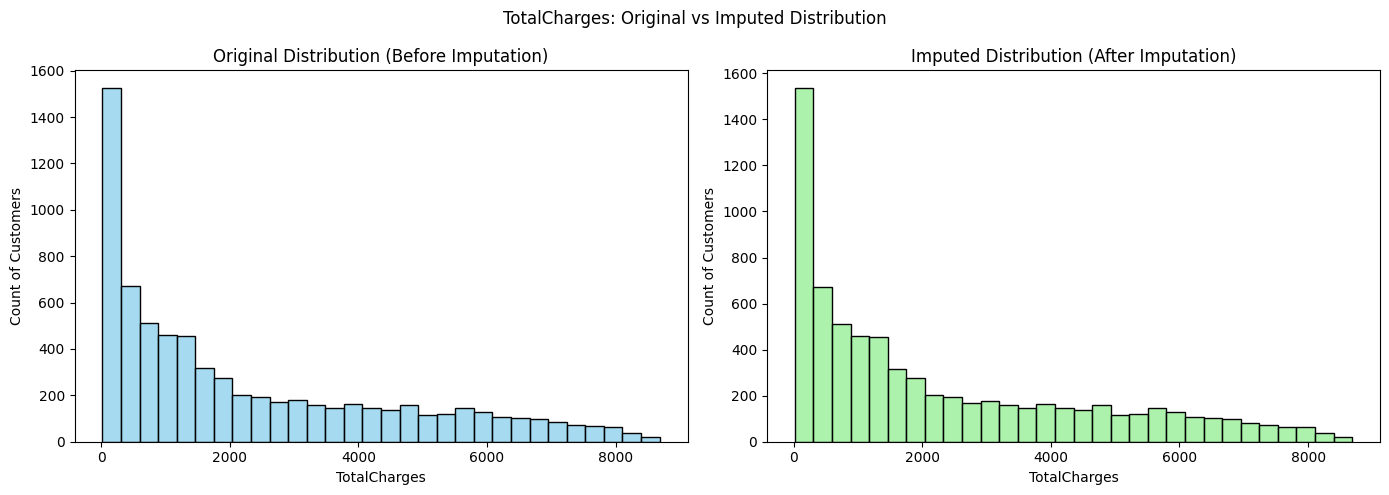

In [ ]:

# load from the original data
raw_data = pd.read_csv('/telco-churn.csv')
raw_data['TotalCharges'] = pd.to_numeric(raw_data['TotalCharges'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# original TotalCharges
sns.histplot(raw_data['TotalCharges'].dropna(), bins=30, color='skyblue', ax=axes[0])
axes[0].set_title('Original Distribution (Before Imputation)')
axes[0].set_ylabel('Count of Customers')

# imputed Totalcharges
sns.histplot(data['TotalCharges'], bins=30, color='lightgreen', ax=axes[1])
axes[1].set_title('Imputed Distribution (After Imputation)')
axes[1].set_ylabel('Count of Customers')

plt.suptitle('TotalCharges: Original vs Imputed Distribution')
plt.tight_layout()
plt.show()

## **Outliers Detection**

---

Both the IQR method and the Z-score method (|Z| > 3) were applied to the numeric columns (`tenure`, `MonthlyCharges`, and `TotalCharges`).
* **Comparison:** Both methods yielded the exact same result: **0 outliers detected**. This indicates that the dataset is highly consistent and free from extreme statistical anomalies.

###**Handle Outliers**
* **Selected Treatment:** Keep (valid business case).

 Since zero outliers were detected by both robust and standard statistical methods, no data modification (such as Capping or Deletion) is needed.

In [ ]:
#outlier detection using (IQR method)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

Q1 = data[num_cols].quantile(0.25)
Q3 = data[num_cols].quantile(0.75)
IQR = Q3 - Q1

outliers_iqr = data[((data[num_cols] < (Q1 - 1.5 * IQR)) | (data[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print(f"Number of outliers detected using IQR method: {len(outliers_iqr)}")

#outlier detection using (Z-score method)
z_scores = (data[num_cols] - data[num_cols].mean()) / data[num_cols].std()

outliers_zscore = data[(z_scores.abs() > 3).any(axis=1)]

print(f"Number of outliers detected using Z-score method: {len(outliers_zscore)}")



Number of outliers detected using IQR method: 0
Number of outliers detected using Z-score method: 0


### **Noise Reduction**
---
* **Technique Applied:** Smoothing by bin means (Equal-frequency binning with **k=4**).

* **Process:** The continuous `MonthlyCharges` column was divided into 4 equal-frequency bins (quantiles). the values within each bin were replaced by the mathematical **mean** of that specific bin.

* **Benefit:** This smoothing technique effectively reduces noise caused by continuous, minor fluctuations in billing amounts. By replacing the values with bin means, we preserve the numerical nature of the feature, ensuring it remains fully compatible with downstream numerical transformations (like MinMaxScaler) without introducing redundant categorical variables.

/tmp/ipykernel_3886/2087318228.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data['MonthlyCharges_binned'] = data.groupby(bins)['MonthlyCharges'].transform('mean').round(2)


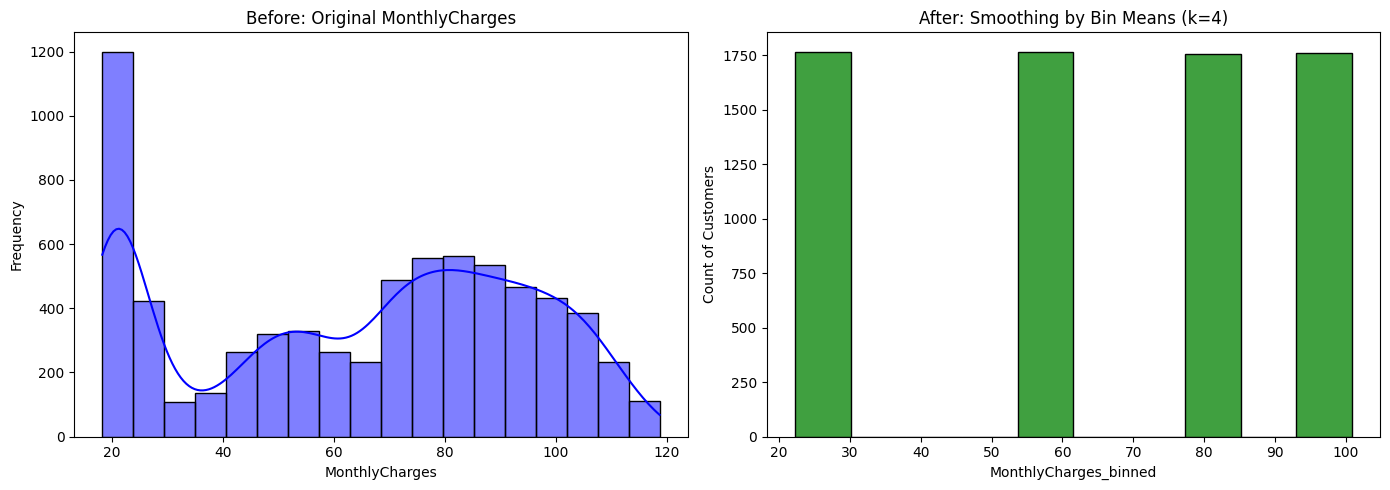

Unique smoothed values in the NEW column:
 [ 22.23  55.73  80.33 100.9 ]


In [ ]:

bins = pd.qcut(data['MonthlyCharges'], q=4)

data['MonthlyCharges_binned'] = data.groupby(bins)['MonthlyCharges'].transform('mean').round(2)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data['MonthlyCharges'], kde=True, ax=axes[0], color='blue')
axes[0].set_title('Before: Original MonthlyCharges')
axes[0].set_ylabel('Frequency')

sns.histplot(data['MonthlyCharges_binned'], kde=False, ax=axes[1], color='green', bins=10)
axes[1].set_title('After: Smoothing by Bin Means (k=4)')
axes[1].set_ylabel('Count of Customers')

plt.tight_layout()
plt.show()

print("Unique smoothed values in the NEW column:\n", data['MonthlyCharges_binned'].unique())

###  **Data Consistency & Validity**

**1. Format Inconsistencies (TotalCharges):**

* **Issue Detected:** The `TotalCharges` column was initially stored as an `object` (string) type instead of a numeric type. This inconsistency occurred because empty values were saved as blank spaces (`' '`) in the raw data.

* **Fix Applied:** convert the column to a `float64` numeric format and converted the hidden blank spaces into standard `NaN` values

In [ ]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

**2. Missing/Invalid Values:**

- **Issue Detected:** The `TotalCharges` column had 11 missing values (`NaN`) specifically in rows where `tenure` equals 0.
- **Fix Applied:** Converted the `NaN` values to the customer's exact `MonthlyCharges` using **Pattern-based Imputation**. Since a tenure of 0 means they are a brand-new customer, their total charge is logically equivalent to their first month's bill.

In [ ]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['MonthlyCharges'])

**3. Categorical consistency**

* **Issue Detected (Redundant Categories):** During the inspection of unique categorical values, I found that several service features (e.g., `OnlineSecurity`, `TechSupport`, `StreamingTV`) contained three classes: `['Yes', 'No', 'No internet service']`. Similarly, `MultipleLines` contained `['Yes', 'No', 'No phone service']`.

* **Logical Analysis:** The values 'No internet service' and 'No phone service' are redundant. Logically, if a customer does not have internet, they inherently do not have online security. Furthermore, the lack of internet or phone service is already captured in the main `InternetService` and `PhoneService` columns.

* **Fix Applied:** I replaced all instances of 'No internet service' and 'No phone service' with 'No' across these 7 columns. This standardizes the features into clean, binary formats (`'Yes'`, `'No'`), removing redundancy and simplifying future model encoding without any information loss.

In [ ]:
internet_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in internet_cols:
    data[col] = data[col].replace('No internet service', 'No')

data['MultipleLines'] = data['MultipleLines'].replace('No phone service', 'No')

for col in data:
    print(f"{col}: {data[col].unique()}")


customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes']
OnlineBackup: ['Yes' 'No']
DeviceProtection: ['No' 'Yes']
TechSupport: ['No' 'Yes']
StreamingTV: ['No' 'Yes']
StreamingMovies: ['No' 'Yes']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
MonthlyCharges: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges: [  29.85 1889.5   108.15 ...  346.45  306.6  6844


**4. Duplicate Records:**
* **Check Performed:** Scanned the entire dataset to identify and remove any exact duplicate rows.

* **Findings:** The dataset was found to be highly unique with zero duplicates.

* **Fix Applied:** Executed the standard `drop_duplicates()` function as a pipeline safeguard.

* **Before / After Documentation:**
  - **Before:** The dataset contained `0` exact duplicate rows (Total shape: 7043 rows).
  - **After:** `0` rows were removed (Total shape remains: 7043 rows). The dataset is clean and free of duplicates.

In [ ]:

duplicates_before = data.duplicated().sum()
print(f"Number of duplicate rows BEFORE: {duplicates_before}")
print(f"Total rows BEFORE: {len(data)}")

data = data.drop_duplicates()

duplicates_after = data.duplicated().sum()
print("-" * 30)
print(f"Number of duplicate rows AFTER: {duplicates_after}")
print(f"Total rows AFTER: {len(data)}")

Number of duplicate rows BEFORE: 0
Total rows BEFORE: 7043
------------------------------
Number of duplicate rows AFTER: 0
Total rows AFTER: 7043


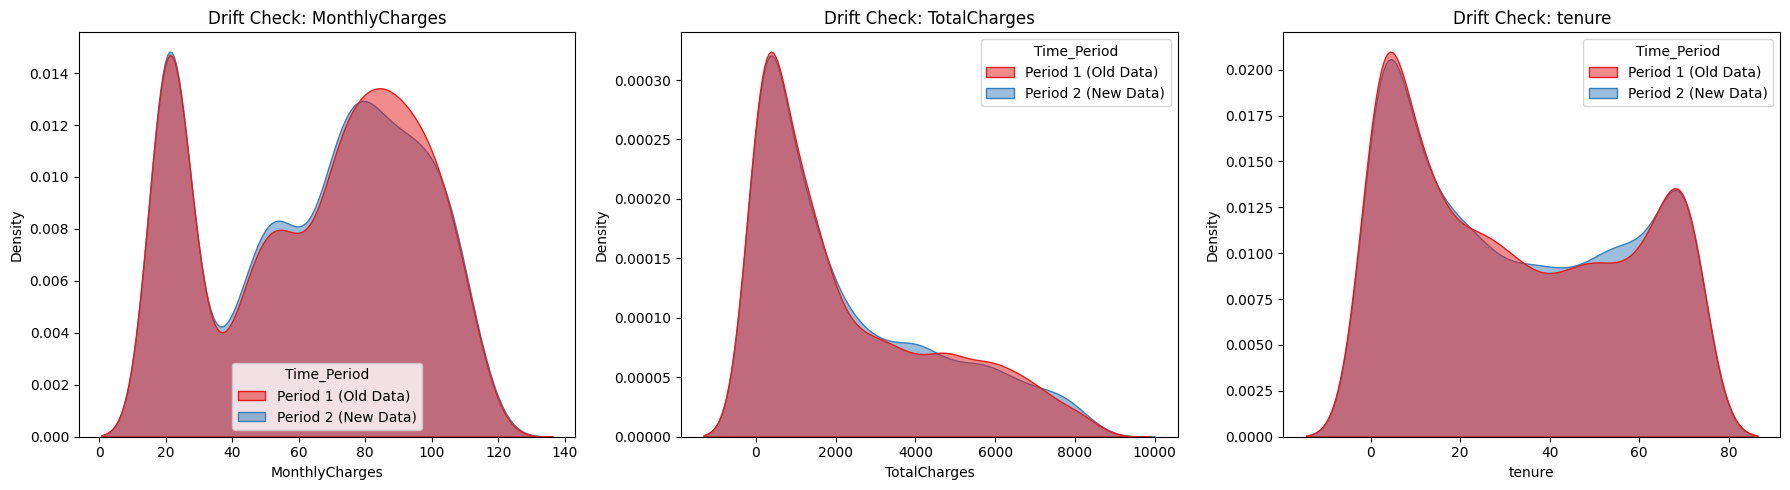

In [ ]:
#Distribution plot showing drift (if splitting data into two time periods)

import matplotlib.pyplot as plt
import seaborn as sns

data_drift = data.copy()

data_drift['TotalCharges'] = pd.to_numeric(data_drift['TotalCharges'], errors='coerce')
data_drift['Time_Period'] = ['Period 1 (Old Data)'] * 3500 + ['Period 2 (New Data)'] * (len(data) - 3500)

features_to_check = ['MonthlyCharges', 'TotalCharges', 'tenure']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(features_to_check):
    sns.kdeplot(data=data_drift, x=col, hue='Time_Period', fill=True, common_norm=False, palette='Set1', alpha=0.5, ax=axes[i])
    axes[i].set_title(f'Drift Check: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()

**3. Distribution Plots Showing Drift (Simulated Time Periods):**


* **Visualization Choice:** KDE (Kernel Density Estimate) plots were generated for all primary numerical features (`MonthlyCharges`, `TotalCharges`, and `tenure`) to compare their distributions across both simulated periods.

* **Findings:** Across all three features, the distributions for Period 1 and Period 2 largely overlap. While there is expected minor statistical noise (natural variance), there is **no severe systemic covariate drift**. The underlying data generation process and customer behavior metrics remained stable across the simulated split.


In [ ]:
import pandas as pd

log_data = [
    {
        "Step": 1,
        "Column": "TotalCharges",
        "Issue Type": "Missing Values",
        "Detection Method": ".isnull() & tenure==0 check",
        "Treatment Applied": "Pattern Imputation (Assigned MonthlyCharges)",
        "Rationale": "New customers (tenure=0) haven't completed a billing cycle",
        "Risk": "None (Logically deterministic)"
    },
    {
        "Step": 2,
        "Column": "Categorical Services (7 cols)",
        "Issue Type": "Categorical Redundancy",
        "Detection Method": ".unique() inspection",
        "Treatment Applied": "Replaced 'No internet/phone service' with 'No'",
        "Rationale": "Eliminate redundant classes for cleaner ML encoding",
        "Risk": "None (Absence of service is covered by main features)"
    },
    {
        "Step": 3,
        "Column": "MonthlyCharges",
        "Issue Type": "Noise / Continuous Fluctuations",
        "Detection Method": "Distribution Analysis",
        "Treatment Applied": "Smoothing by bin means (k=4)",
        "Rationale": "Reduce noise from minor billing variations to highlight broader spending patterns",
        "Risk": "Loss of absolute precision (cents/dollars are replaced by bin averages)"
    },
    {
        "Step": 4,
        "Column": "MonthlyCharges, tenure , TotalCharges",
        "Issue Type": "Outliers",
        "Detection Method": "IQR & Z-score (|Z| > 3)",
        "Treatment Applied": "None (0 outliers found)",
        "Rationale": "Data is naturally bounded and realistic",
        "Risk": "None"
    },
    {
        "Step": 5,
        "Column": "All Dataset",
        "Issue Type": "Duplicate Records",
        "Detection Method": ".duplicated().sum()",
        "Treatment Applied": "drop_duplicates()",
        "Rationale": "Pipeline safeguard to prevent model overfitting",
        "Risk": "None (0 duplicates removed)"
    },

]

cleaning_log_df = pd.DataFrame(log_data)

display(cleaning_log_df)

,Step,Column,Issue Type,Detection Method,Treatment Applied,Rationale,Risk
0,1,TotalCharges,Missing Values,.isnull() & tenure==0 check,Pattern Imputation (Assigned MonthlyCharges),New customers (tenure=0) haven't completed a b...,None (Logically deterministic)
1,2,Categorical Services (7 cols),Categorical Redundancy,.unique() inspection,Replaced 'No internet/phone service' with 'No',Eliminate redundant classes for cleaner ML enc...,None (Absence of service is covered by main fe...
2,3,MonthlyCharges,Noise / Continuous Fluctuations,Distribution Analysis,Smoothing by bin means (k=4),Reduce noise from minor billing variations to ...,Loss of absolute precision (cents/dollars are ...
3,4,"MonthlyCharges, tenure , TotalCharges",Outliers,IQR & Z-score (|Z| > 3),None (0 outliers found),Data is naturally bounded and realistic,None
4,5,All Dataset,Duplicate Records,.duplicated().sum(),drop_duplicates(),Pipeline safeguard to prevent model overfitting,None (0 duplicates removed)


In [ ]:
data.to_csv('cleaned_telco.csv', index=False)